# 原型网络：5-shot 的五个样本是什么？

分清 meta-training 标签预算与单任务支持集。主示范采用类别不相交划分；同场景 patch 仍可能共享空间上下文。

默认 demo 加载预先训练权重，核心算法在下方逐步演示。旧实验数字不作为本次结果。

In [1]:
from pathlib import Path
import sys
ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / 'src/hsi_learning').is_dir() and (p / 'dataset').is_dir()), None)
if ROOT is None:
    raise RuntimeError('Open this notebook from inside the HSI-Learning repository')
sys.path.insert(0, str(ROOT / 'src'))
import numpy as np
import torch
# Notebook kernels must explicitly use inline rendering even when the CLI
# parent uses MPLBACKEND=Agg for non-interactive training scripts.
from IPython import get_ipython
get_ipython().run_line_magic('matplotlib', 'inline')
from matplotlib_inline.backend_inline import set_matplotlib_formats
set_matplotlib_formats('png')
import matplotlib.pyplot as plt
from hsi_learning.data import load_hsi_dataset
from hsi_learning.teaching_runs import load_bundle, encode_ids
from hsi_learning.teaching import patches_at, prototype_logits, prototypes, grad_cam
from hsi_learning.teaching_plots import style, maps
style()
torch.set_num_threads(2)
print('Python:', sys.executable)
print('Repository:', ROOT)


Python: D:\DevSpace\HSI-Learning\.venv\Scripts\python.exe
Repository: D:\DevSpace\HSI-Learning


In [2]:
# Classroom mode NEVER silently starts training.
MODE = 'demo'  # 'train' explicitly starts the full preparation queue below
BUNDLE_ROOT = ROOT / 'results/teaching_ready'
if MODE == 'train':
    import subprocess
    subprocess.run([sys.executable, str(ROOT/'scripts/prepare_teaching_artifacts.py')], check=True)
elif MODE != 'demo':
    raise ValueError('MODE must be demo or train')


In [3]:
model, cube, gt, names, split, cfg = load_bundle(BUNDLE_ROOT/'protonet')
print('Class split:', cfg['classes'])
print('Meta-training annotated centers:', len(split['train_ids']))
print('Preprocessing:', cfg['preprocessing'])
assert not (set(cfg['classes']['train']) & set(cfg['classes']['test']))


Class split: {'train': [2, 3, 5, 6, 10, 11], 'val': [1, 4, 7, 8, 9], 'test': [12, 13, 14, 15, 16]}
Meta-training annotated centers: 6898
Preprocessing: PCA+scaler fit meta-training centers only


## Support / Query
每类10个可用支持位置、5个查询位置。缩小 K 时保留相同查询任务；不得把查询标签用于建原型。

Episode classes: [13 16 12 15 14] support: 25 query: 25


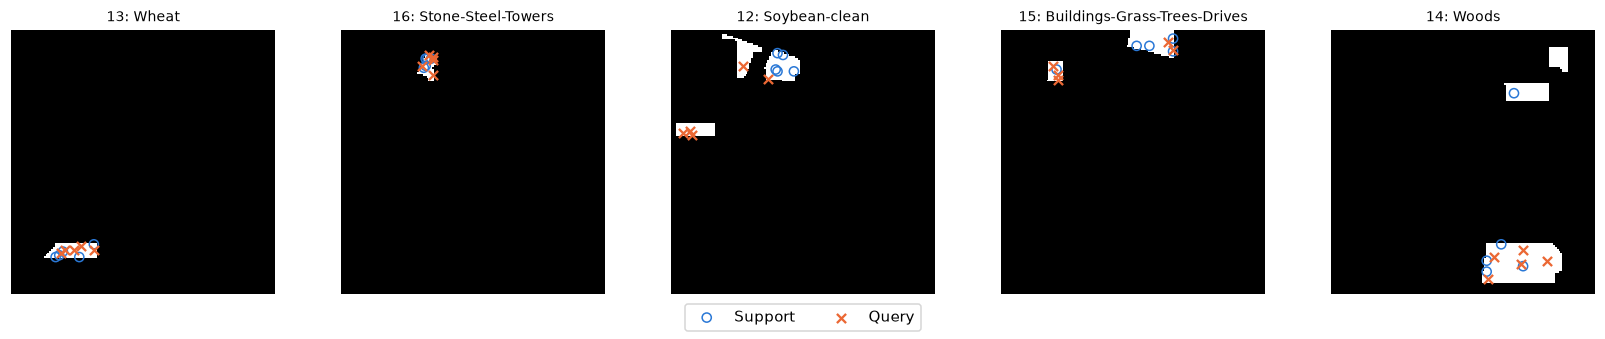

In [4]:
from hsi_learning.teaching import Episode
from hsi_learning.teaching_plots import episode_figure
classes = split['episode_classes'][0]
support = split['episode_support'][0].reshape(5,10)[:,:5].ravel()
query = split['episode_query'][0]
ep = Episode(classes, support, query, np.repeat(np.arange(5),5), np.repeat(np.arange(5),5))
assert not set(support) & set(query)
print('Episode classes:',classes,'support:',len(support),'query:',len(query))
episode_figure(gt,ep,names)


## 类均值与负平方距离
先手算二维例子，再对真实嵌入运行同一函数。

In [5]:
s=torch.tensor([[0.,0.],[2.,0.],[8.,0.],[10.,0.]])
y=torch.tensor([0,0,1,1]); q=torch.tensor([[4.,0.]])
print('Hand-check logits (expected -9,-25):',prototype_logits(s,y,q,2))
with torch.no_grad():
    se=model(patches_at(cube,support)); qe=model(patches_at(cube,query))
    logits=prototype_logits(se,torch.as_tensor(ep.support_y),qe,5)
print('Episode accuracy:', float((logits.argmax(1)==torch.as_tensor(ep.query_y)).float().mean()))


Hand-check logits (expected -9,-25): tensor([[ -9., -25.]])
Episode accuracy: 0.800000011920929


Same encoder; fixed class pool and paired queries:
1 shot: 0.6626666694879532 episode std: 0.08768805431066222
5 shot: 0.8066666642824809 episode std: 0.08856454019216768
10 shot: 0.8120000044504802 episode std: 0.08735184302759415


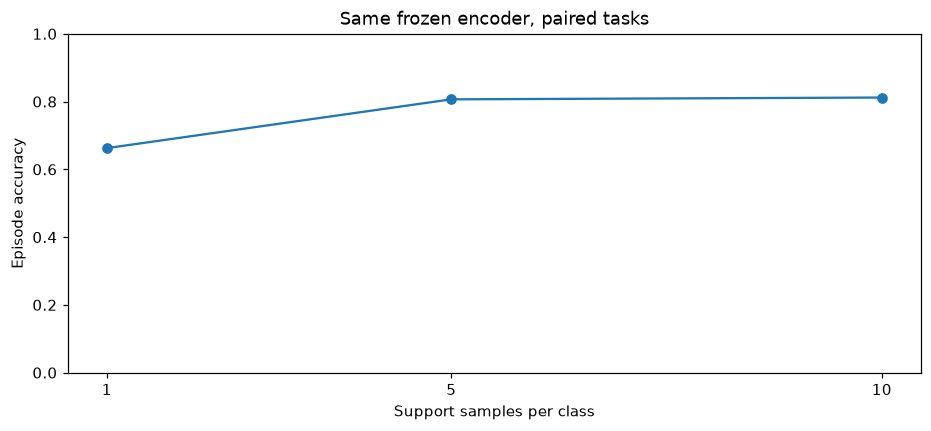

In [6]:
import json
metrics=json.loads((BUNDLE_ROOT/'protonet/metrics.json').read_text())
print('Same encoder; fixed class pool and paired queries:')
for k,v in metrics['kshot'].items(): print(k, 'shot:', v['mean'], 'episode std:',v['episode_std'])
plt.plot([1,5,10],[metrics['kshot'][str(k)]['mean'] for k in [1,5,10]],'o-')
plt.xticks([1,5,10]); plt.xlabel('Support samples per class'); plt.ylabel('Episode accuracy')
plt.ylim(0,1); plt.title('Same frozen encoder, paired tasks'); plt.show()


## 全图演示（不是另一项测试成绩）
只用当前 episode 的五类支持集建原型。全图像元会被强制分到这五类；其他类别不是本任务的可识别类别。GT 仅用于显示与诊断。

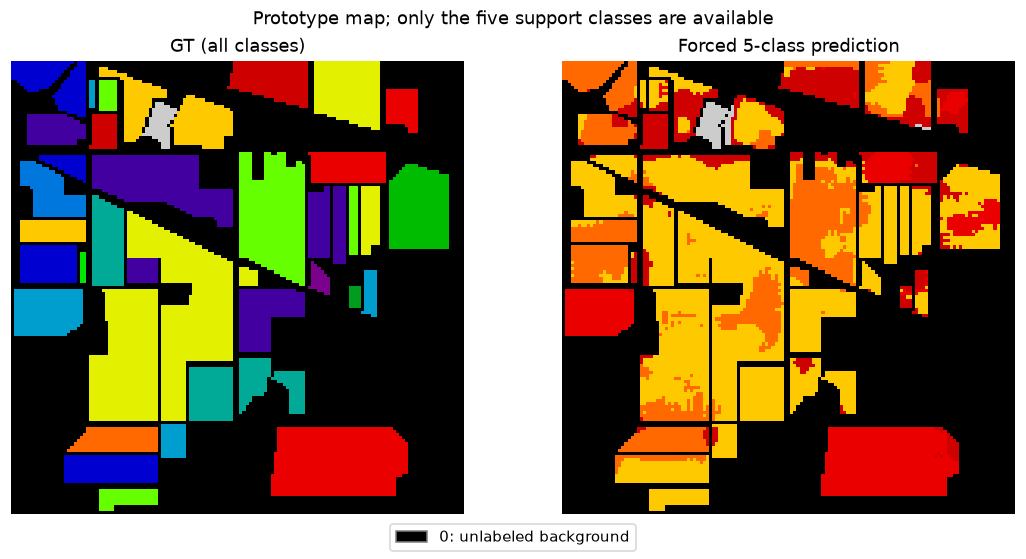

Class IDs: {1: 'Alfalfa', 2: 'Corn-notill', 3: 'Corn-mintill', 4: 'Corn', 5: 'Grass-pasture', 6: 'Grass-trees', 7: 'Grass-pasture-mowed', 8: 'Hay-windrowed', 9: 'Oats', 10: 'Soybean-notill', 11: 'Soybean-mintill', 12: 'Soybean-clean', 13: 'Wheat', 14: 'Woods', 15: 'Buildings-Grass-Trees-Drives', 16: 'Stone-Steel-Towers'}
Support IDs and class mapping are recorded in split.npz; this map is not 16-class OA.


In [7]:
all_emb=encode_ids(model,cube,np.arange(gt.size))
with torch.no_grad():
    centers=prototypes(se,torch.as_tensor(ep.support_y),range(5))
    nearest=torch.cdist(all_emb,centers).argmin(1).numpy()
pred=classes[nearest].reshape(gt.shape)
panels={'GT (all classes)':gt,'Forced 5-class prediction':np.where(gt>0,pred,0)}
maps(gt,panels,names,'Prototype map; only the five support classes are available')
print('Support IDs and class mapping are recorded in split.npz; this map is not 16-class OA.')


## 练习与限制
固定查询，只改 K，再检查个别任务是否一定提升。解释为什么25不是encoder总训练标签数。

类别不交不等于空间不交；训练/验证/测试任务在CLI中独立。经典来源：Snell et al., NeurIPS 2017。